# 图表反演

In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

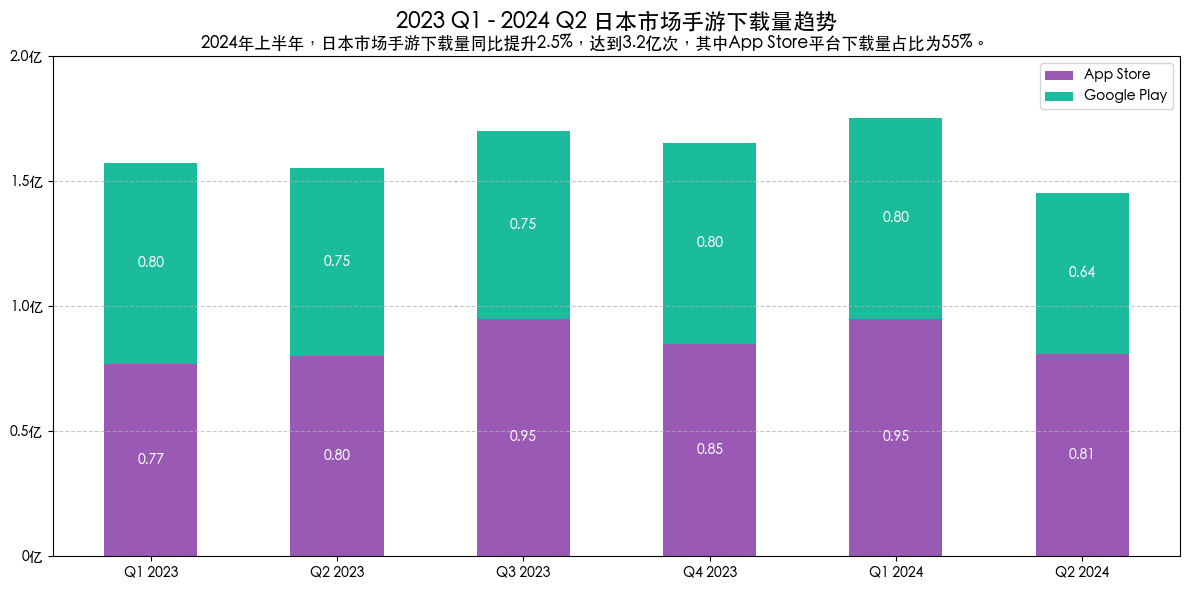

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 设置季度数据
quarters = ['Q1 2023', 'Q2 2023', 'Q3 2023', 'Q4 2023', 'Q1 2024', 'Q2 2024']
# App Store 下载量数据（单位：亿次），调整后Q1 2024 + Q2 2024 ≈ 1.76
app_store = [0.77, 0.8, 0.95, 0.85, 0.95, 0.81]  
# Google Play 下载量数据（单位：亿次），调整后Q1 2024 + Q2 2024 ≈ 1.44
google_play = [0.8, 0.75, 0.75, 0.8, 0.8, 0.64]  

x = np.arange(len(quarters))  # x轴刻度位置
width = 0.5  # 增加柱子宽度

# 创建更宽的图表（宽度12，高度6）
fig, ax = plt.subplots(figsize=(12, 6))

# 绘制 App Store 柱子（底部）
rects1 = ax.bar(x, app_store, width, label='App Store', color='#9b59b6')
# 绘制 Google Play 柱子（顶部）
rects2 = ax.bar(x, google_play, width, bottom=app_store, label='Google Play', color='#1abc9c')

# 设置x轴刻度标签和旋转角度
ax.set_xticks(x)
ax.set_xticklabels(quarters, rotation=0)  # 水平显示季度标签

# 设置y轴范围和刻度
ax.set_ylim(0, 2.0)
ax.set_yticks([0, 0.5, 1.0, 1.5, 2.0])
ax.set_yticklabels(['0亿', '0.5亿', '1.0亿', '1.5亿', '2.0亿'])

# 添加数据标签（修改为保留两位小数）
def add_labels(rects, bottom_values=None):
    for i, rect in enumerate(rects):
        height = rect.get_height()
        if bottom_values is not None:
            y_pos = bottom_values[i] + height / 2
        else:
            y_pos = height / 2
        # 格式化显示为两位小数
        ax.text(rect.get_x() + rect.get_width()/2., y_pos,
                f'{height:.2f}', ha='center', va='center', color='white', fontweight='bold')

add_labels(rects1)  # App Store 标签
add_labels(rects2, app_store)  # Google Play 标签

# 添加图例和标题
ax.legend(loc='upper right')
ax.set_title('2023 Q1 - 2024 Q2 日本市场手游下载量趋势', fontsize=16, pad=20)

# 添加网格线
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 在标题下方添加指定文字（调整y坐标为0.92）
text = "2024年上半年，日本市场手游下载量同比提升2.5%，达到3.2亿次，其中App Store平台下载量占比为55%。"
fig.text(0.5, 0.92, text, ha='center', va='center', fontsize=12)

# 调整布局
plt.tight_layout()

plt.show()

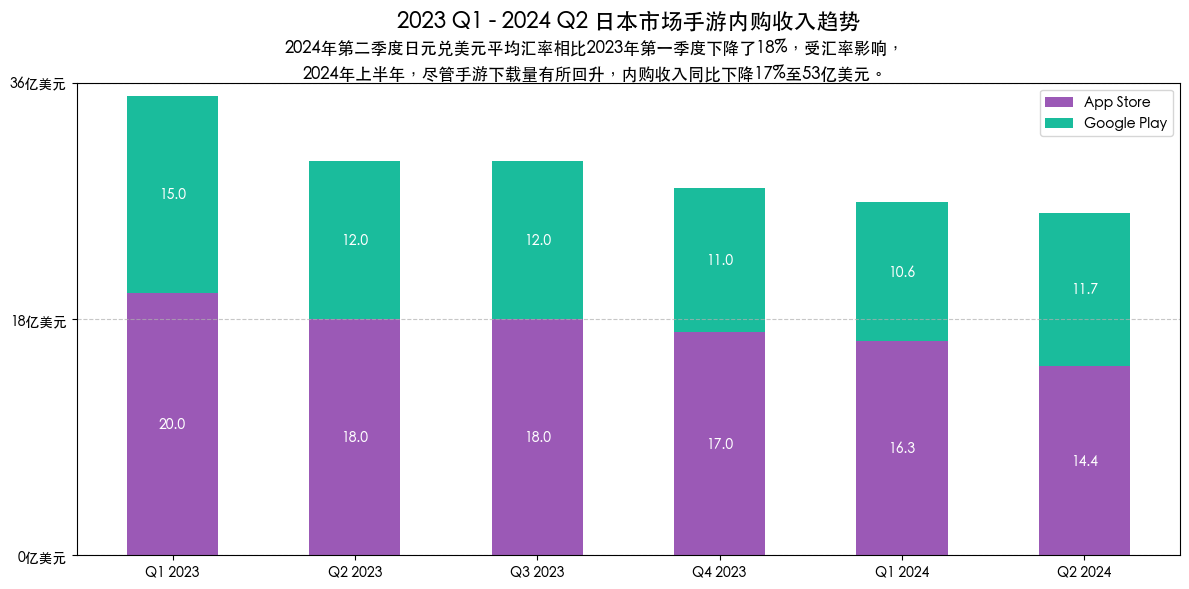

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 季度数据
quarters = ['Q1 2023', 'Q2 2023', 'Q3 2023', 'Q4 2023', 'Q1 2024', 'Q2 2024']
# App Store 内购收入（单位：亿美元，模拟数据贴近图表比例）
app_store = [20, 18, 18, 17, 16.3, 14.4]  
# Google Play 内购收入（单位：亿美元，模拟数据贴近图表比例）
google_play = [15, 12, 12, 11, 10.6, 11.7]

x = np.arange(len(quarters))  # x 轴刻度位置
width = 0.5  # 柱子宽度，让图表更紧凑美观

# 创建画布，设置尺寸
fig, ax = plt.subplots(figsize=(12, 6))

# 绘制 App Store 柱子（底部，紫色）
rects1 = ax.bar(x, app_store, width, label='App Store', color='#9b59b6')
# 绘制 Google Play 柱子（顶部，青色，底部基于 App Store 数据堆叠）
rects2 = ax.bar(x, google_play, width, bottom=app_store, label='Google Play', color='#1abc9c')

# 设置 x 轴刻度与标签，水平显示
ax.set_xticks(x)
ax.set_xticklabels(quarters, rotation=0)  

# 设置 y 轴范围与刻度，匹配图表的“0、18、36 亿美元”量级
ax.set_ylim(0, 36)
ax.set_yticks([0, 18, 36])
ax.set_yticklabels(['0亿美元', '18亿美元', '36亿美元'])

# 添加数据标签函数，显示柱子高度（保留1位小数）
def add_labels(rects, bottom_values=None):
    for i, rect in enumerate(rects):
        height = rect.get_height()
        y_pos = bottom_values[i] + height / 2 if bottom_values is not None else height / 2
        ax.text(
            rect.get_x() + rect.get_width()/2., 
            y_pos,
            f'{height:.1f}',  # 关键修改：强制保留1位小数
            ha='center', 
            va='center', 
            color='white', 
            fontweight='bold'
        )

add_labels(rects1)  # App Store 数据标签
add_labels(rects2, app_store)  # Google Play 数据标签

# 图例、标题设置
ax.legend(loc='upper right')
ax.set_title('2023 Q1 - 2024 Q2 日本市场手游内购收入趋势', fontsize=16, pad=40)

# 添加网格线，辅助观察数据
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 图表上方说明文字，还原业务背景
text = ("2024年第二季度日元兑美元平均汇率相比2023年第一季度下降了18%，受汇率影响，\n"
        "2024年上半年，尽管手游下载量有所回升，内购收入同比下降17%至53亿美元。")
# 调整文字位置，避免与标题重叠
fig.text(0.5, 0.89, text, ha='center', va='center', fontsize=12, linespacing=1.5)

# 自动优化布局，确保元素不挤压
plt.tight_layout()

plt.show()